In [1]:
# | Score range | Severe Level (low/mediium/high) | Example snippet | Reasons

In [2]:
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt

In [3]:
result_paths = glob.glob('./Result/analysis_reports_labeled/*')
result_paths = sorted(result_paths, key=lambda x: x.split('/')[-1])

In [4]:
keys = [-6, -5, -4, -3, -2, -1, -0.5, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
reason_dict = {k: [] for k in keys}
snippet_dict = {k: '*'*10000 for k in keys}
score_list_1a = []
sum_score_list_1a = []
sum_score_list_7 = []
score_list_7 = []
threshold = 70

for f_p in (result_paths):
    with open(f_p, 'r', encoding='utf-8') as f:
        result = json.load(f)[0]
    # company_name = f_p.split('/')[-1].split('_')[0]
    # date = f_p.split('/')[-1].split('_')[1].split('.')[0]
    
    evidence_list = result['evidence_list']
    for i, evidence in enumerate(evidence_list):
        snippet = evidence['snippet']
        components = evidence['score_calculation']['components']
        label = evidence['item_label']
        score_1a = 0
        score_7 = 0
        count_1a = 0
        count_7 = 0
        for c in components:
            points = c['points']
            reason = c['reason']

            if len(snippet) < len(snippet_dict[points]) and len(snippet) > threshold:
                snippet_dict[points] = snippet
                reason_dict[points] = reason
            if points == 3 and label == 'item_7':
                print(evidence['snippet'])
                print(c['reason'])
                print(c['points'])
                # print(f'{result_paths}')

            if label == 'item_1a' or label == 'item_1a, item_7':
                score_list_1a.append(points)
                score_1a += points
                count_1a += 1
            elif label == 'item_7' or label == 'item_1a, item_7':
                score_list_7.append(points)
                score_7 += points
                count_7 += 1
        if count_1a > 0:
            sum_score_list_1a.append(score_1a)
        if count_7 > 0:
            sum_score_list_7.append(score_7)

print(set(sum_score_list_1a))
print(set(sum_score_list_7))

During the fourth quarter of 2021, certain of the Company’s component suppliers and logistical service providers experienced disruptions, resulting in supply shortages that affected sales worldwide.
Explicit link to worldwide sales impact.
3
AbbVie expects this matter could continue to negatively impact its results of operations throughout the duration of the outbreak.
Forecasts ongoing negative impact on results of operations.
3
While the impact of COVID-19 on AbbVie's operations to date has not been material, AbbVie continues to experience lower new patient starts in certain products and markets.
Notes ongoing tangible negative outcome (lower new patient starts).
3
AbbVie expects this matter could continue to negatively impact its results of operations throughout the duration of the pandemic.
Forecasts ongoing negative effect on results of operations.
3
The coronavirus (COVID-19) pandemic affected Abbott’s diversified health care businesses in various ways over the 2020 through 2022 

In [5]:
snippet_dict

{-6: 'Because we sell products that are essential to the daily lives of consumers, the pandemic has not had a materially negative impact to our consolidated net sales, net earnings and cash flows.',
 -5: 'The pandemic did not materially and adversely impact our overall operating results or business operations during 2020.',
 -4: 'The company’s overall 2020 revenue and operating income were not significantly impacted by COVID-19.',
 -3: 'We expect bad debt expense and churn in 2021 to return to pre-pandemic levels.',
 -2: 'In 2023, commercial services volume at BGS exceeded pre-pandemic levels.',
 -1: 'In addition, consumers returned to more pre-pandemic shopping patterns.',
 -0.5: 'The net sales decrease was due to a 15% organic sales decline driven by a weak global economy as a result of the COVID-19 pandemic, partially offset by the acquisitions of Gatan and IntelliPower.',
 0: 'Senior housing communities have been disproportionately impacted by COVID-19.',
 1: 'The pandemic also res

In [6]:
reason_dict

{-6: 'Explicitly states limited historical financial damage—strong mitigating factor.',
 -5: 'Affirmative statement of no material impact to date (strong mitigation).',
 -4: 'States limited 2020 financial impact, a significant mitigant.',
 -3: 'Provides mitigating outlook—anticipates recovery in 2021.',
 -2: 'Demonstrates that at least one business segment has surpassed pre-pandemic performance, reducing perceived risk.',
 -1: 'Effect is descriptive but not labeled as adverse or quantified.',
 -0.5: 'Mentions partial mitigating effect of acquisitions.',
 0: 'Generic statement without financial quantification.',
 1: 'Global scope underscores breadth of impact.',
 2: 'Forward-looking warning of further supply disruption.',
 3: 'Uses present-tense language (creates) indicating current impact, not merely potential.',
 4: 'Explicitly identifies COVID-19 as a risk source for the business.',
 5: 'Highlights dependency on freight carrier continuity.',
 6: 'Provides explicit, quantified financi

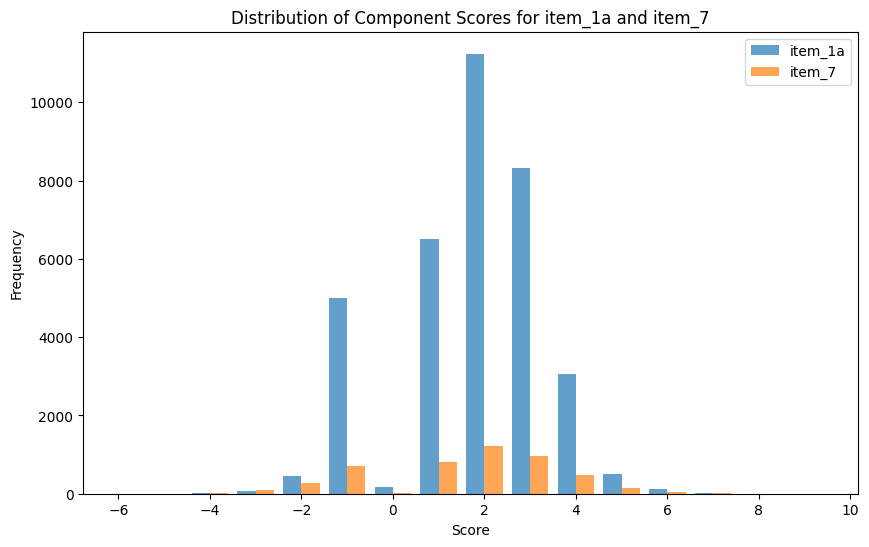

In [7]:
# plt.hist(score_list, bins=17, edgecolor='black')

fig, ax = plt.subplots(figsize=(10, 6))
counts_1a = pd.Series(score_list_1a).value_counts().sort_index()
counts_7 = pd.Series(score_list_7).value_counts().sort_index()

bar_width = 0.4
x = counts_1a.index

ax.bar(x - bar_width/2, counts_1a.values, width=bar_width, alpha=0.7, label='item_1a')
ax.bar(counts_7.index + bar_width/2, counts_7.values, width=bar_width, alpha=0.7, label='item_7')

ax.set_title('Distribution of Component Scores for item_1a and item_7')
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

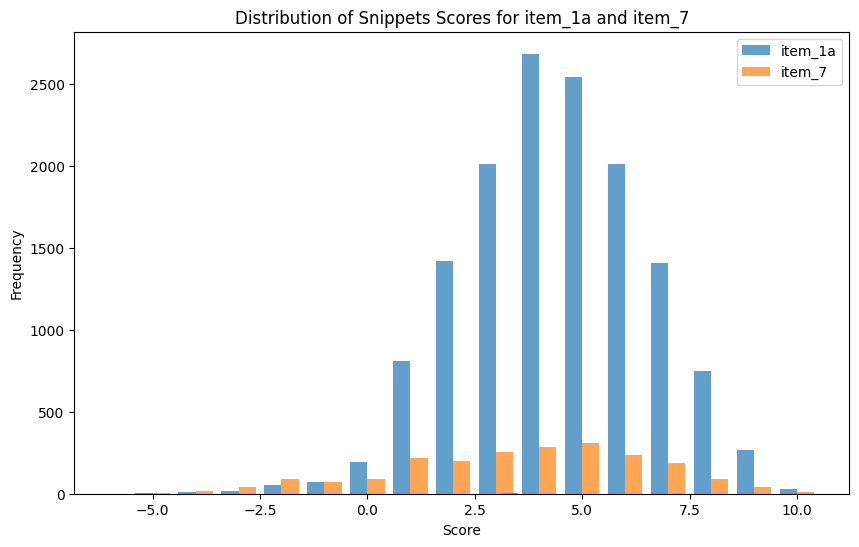

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
counts_1a = pd.Series(sum_score_list_1a).value_counts().sort_index()
counts_7 = pd.Series(sum_score_list_7).value_counts().sort_index()

bar_width = 0.4
x = counts_1a.index

ax.bar(x - bar_width/2, counts_1a.values, width=bar_width, alpha=0.7, label='item_1a')
ax.bar(counts_7.index + bar_width/2, counts_7.values, width=bar_width, alpha=0.7, label='item_7')

ax.set_title('Distribution of Snippets Scores for item_1a and item_7')
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

In [21]:
counts_7

-6.0       1
-5.0       6
-4.0      15
-3.0      40
-2.0      88
-1.0      73
 0.0      90
 1.0     219
 2.0     202
 3.0     257
 4.0     283
 5.0     312
 6.0     235
 6.5       1
 7.0     190
 8.0      91
 9.0      40
 10.0     11
Name: count, dtype: int64

In [10]:
counts_1a[:-2].values.sum()/counts_1a.values.sum()

/var/folders/f2/4wvlw_2n48ncjhv0cwccstmc0000gn/T/ipykernel_6433/4271568774.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  counts_1a[:-2].values.sum()/counts_1a.values.sum()


0.006299433051025408

In [20]:
counts_7[:0].values.sum()/counts_7.values.sum()

/var/folders/f2/4wvlw_2n48ncjhv0cwccstmc0000gn/T/ipykernel_6433/1407534829.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  counts_7[:0].values.sum()/counts_7.values.sum()


0.14531104921077065

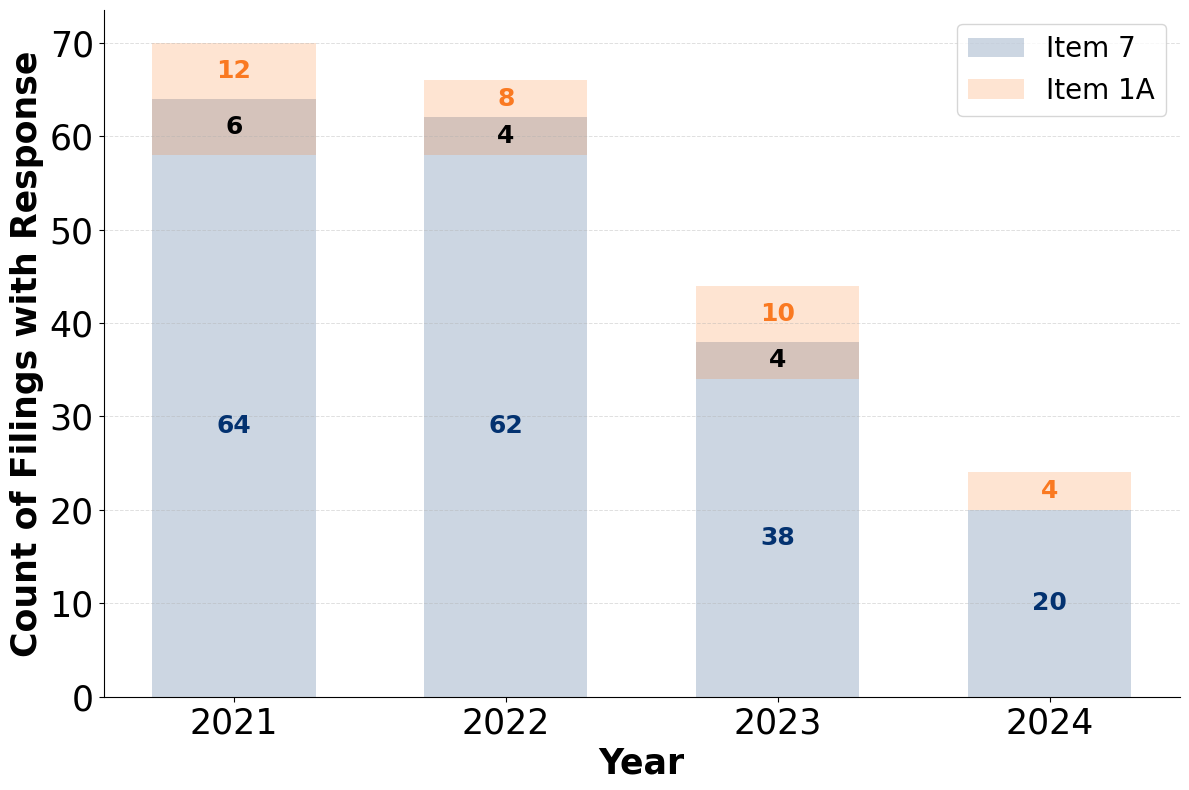

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ── 你的四年统计：替换成真实数字 ──────────────────────────────
years   = ['2021', '2022', '2023', '2024']
n_1a    = [12, 8, 10, 4]   # Item 1A  响应数（含交集）
n_7     = [64, 62, 38, 20]   # Item 7   响应数（含交集）
n_both  = [70, 66, 44, 24]   # 两者都有
# ────────────────────────────────────────────────────────────

overlap = [a + b - y for y, a, b in zip(n_both, n_1a, n_7)]
bottom_1a = [b - c for b, c in zip(n_7, overlap)]

x = np.arange(len(years))
fig, ax = plt.subplots(figsize=(12, 8))

# ── 1. 先画 7-only（蓝色底座） ───────────────────────────────
bars_7 = ax.bar(x, n_7, width=0.6,
               color='#033270', alpha=0.2, label='Item 7')

# ── 2. 再画 1A “总柱” (only_1a + both) ，底边 = only_7 ───────
bars_1a = ax.bar(x, n_1a, width=0.6,
                bottom=bottom_1a,
                color='#fa7921', alpha=0.2, label='Item 1A')

# ── 3. 标注数字 ─────────────────────────────────────────────
for xi, y7, y1at, both, o1, overlap in zip(x, n_7, n_1a, n_both, n_1a, overlap):
    # 7
    ax.text(xi, (y7-overlap)/2, str(y7), ha='center', va='center',
            color='#033270', fontsize=18, weight='bold')
    # 1a
    ax.text(xi, (both-y7)/2+y7, str(y1at), ha='center', va='center',
            color='#fa7921', fontsize=18, weight='bold')
    # overlap
    if overlap > 0:
        ax.text(xi, y7 - overlap/2, str(overlap), ha='center', va='center',
                color='black', fontsize=18, weight='bold')

# ── 4. 轴标签 / 风格 ────────────────
ax.set_xticks(x); 
ax.set_xticklabels(years, fontsize=25)
ax.set_ylabel('Count of Filings with Response', fontsize=25, fontweight='bold')
ax.set_xlabel('Year', fontsize=25, fontweight='bold')
ax.tick_params(axis='y', labelsize=25)
# ax.set_title('Item 1A vs Item 7: α-blend & shifted\n(1A starts at height of 7-only)')
ax.legend()
ax.spines[['right', 'top']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.7)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('./Figs/result_response_in_1a_7.pdf', bbox_inches='tight', dpi=600)
plt.show()

